In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Dataset
iris = load_iris()

X = iris.data
y = iris.target


# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Decision Tree
tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)


# Random Forest
forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)


# Compare
print(
    "Decision Tree:",
    accuracy_score(y_test, tree_pred)
)

print(
    "Random Forest:",
    accuracy_score(y_test, forest_pred)
)

Decision Tree: 0.9333333333333333
Random Forest: 0.9666666666666667


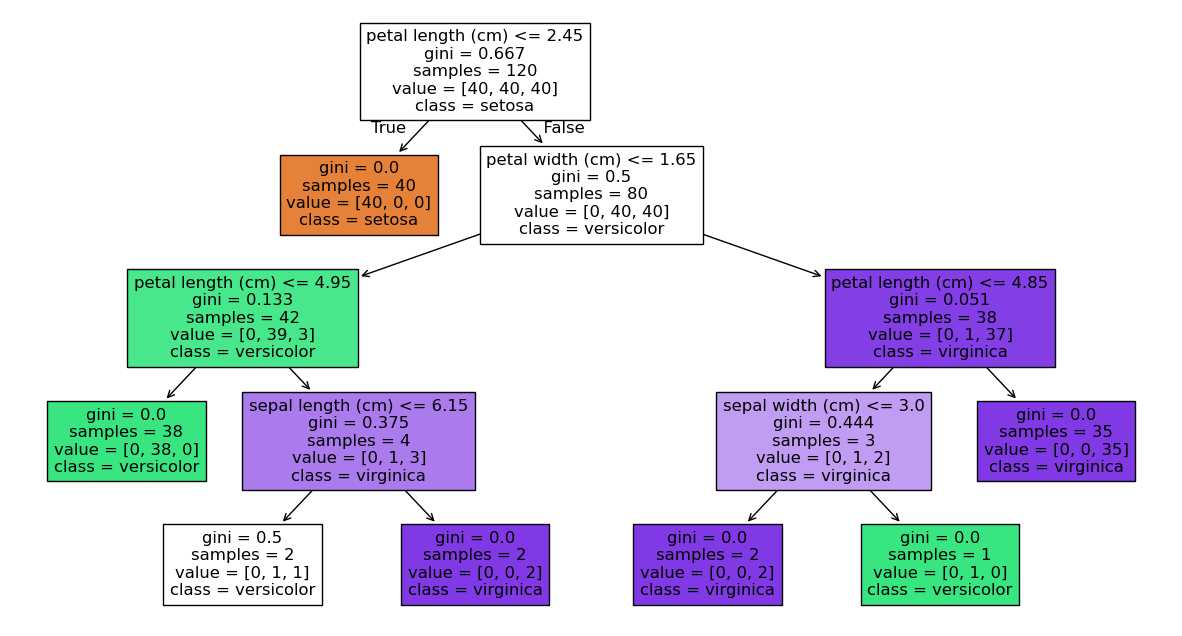

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


plt.figure(figsize=(15, 8))

plot_tree(
    tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

In [8]:
import pandas as pd

importance = pd.Series(
    tree.feature_importances_,
    index=iris.feature_names
)

print(
    importance.sort_values(
        ascending=False
    )
)

petal length (cm)    0.565639
petal width (cm)     0.411154
sepal width (cm)     0.016878
sepal length (cm)    0.006329
dtype: float64


<Axes: >

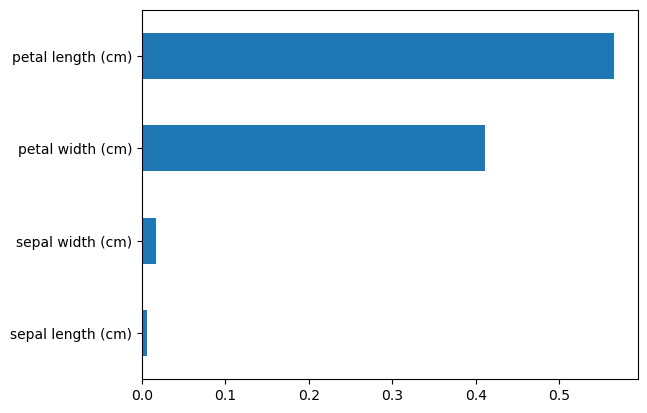

In [9]:
importance.sort_values().plot(
    kind="barh"
)